## Инжиниринг численных признаков

### Классная работа

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler

In [7]:
prsa_data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.2%20numeric%20features/data/PRSA_Data.csv", index_col=0)
prsa_data.head()

,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,3,-1.0,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,4,8.0,14.0,-1.0,-1.000000,1024.5,0.0,NW,3.1,Excellent
4,5,9.0,-1.0,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


In [9]:
prsa_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35064 entries, 0 to 35063
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   No         35064 non-null  int64  
 1   SO2        35064 non-null  float64
 2   NO2        35064 non-null  float64
 3   CO         35064 non-null  float64
 4   O3         35064 non-null  float64
 5   PRES       35064 non-null  float64
 6   RAIN       35064 non-null  float64
 7   wd         35064 non-null  object 
 8   WSPM       35064 non-null  float64
 9   AQI Label  35064 non-null  object 
dtypes: float64(7), int64(1), object(2)
memory usage: 2.9+ MB


In [11]:
prsa_data.describe()

,No,SO2,NO2,CO,O3,PRES,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,17532.500000,18.058734,63.236861,1251.121692,45.876835,1010.520250,0.067653,1.500217
std,10122.249256,22.558126,39.109232,1269.033556,54.730861,26.289217,0.896833,1.105382
min,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,8766.750000,4.000000,34.000000,500.000000,2.397428,1002.500000,0.000000,0.800000
50%,17532.500000,10.000000,58.000000,900.000000,27.356346,1010.800000,0.000000,1.200000
75%,26298.250000,22.276800,87.000000,1500.000000,69.548316,1019.400000,0.000000,2.000000
max,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,72.500000,11.200000


#### Идентификация ошибочных значений

In [17]:
prsa_data[prsa_data == -1] = np.nan
prsa_data.head()

,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,3,NaN,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,4,8.0,14.0,NaN,NaN,1024.5,0.0,NW,3.1,Excellent
4,5,9.0,NaN,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


#### Визуализация распределения атрибутов

<Axes: xlabel='SO2', ylabel='Count'>

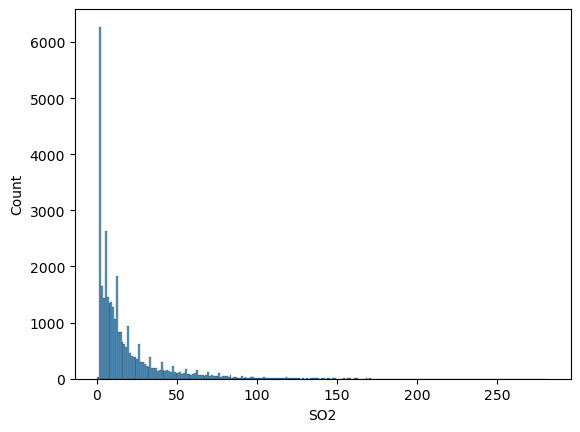

In [20]:
sns.histplot(prsa_data.SO2)

<Axes: xlabel='NO2', ylabel='Density'>

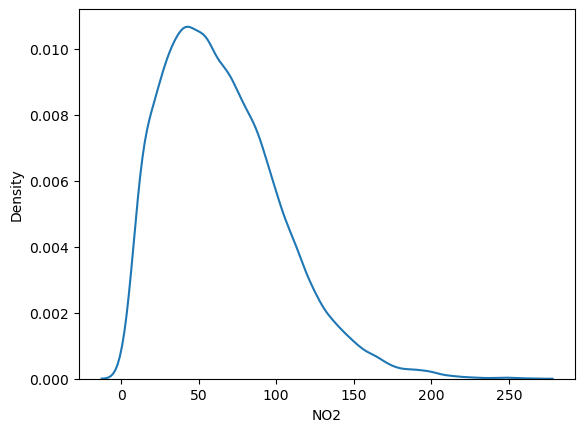

In [22]:
sns.kdeplot(prsa_data.NO2)

<Axes: xlabel='CO', ylabel='Count'>

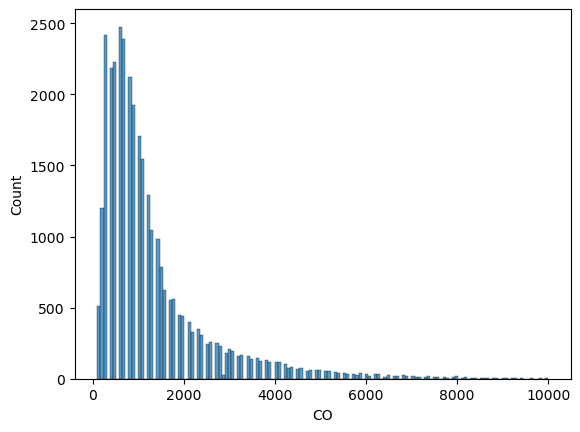

In [24]:
sns.histplot(prsa_data.CO)

<Axes: xlabel='O3', ylabel='Count'>

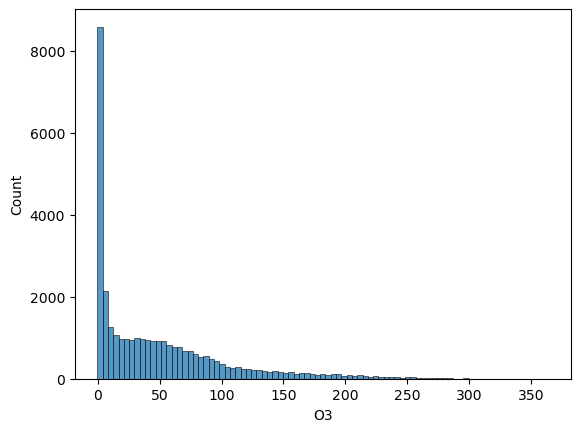

In [26]:
sns.histplot(prsa_data.O3)

<Axes: xlabel='PRES', ylabel='Count'>

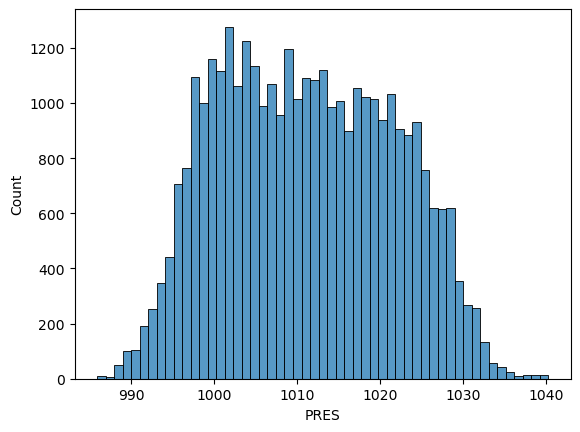

In [28]:
sns.histplot(prsa_data.PRES)

<Axes: xlabel='RAIN', ylabel='Count'>

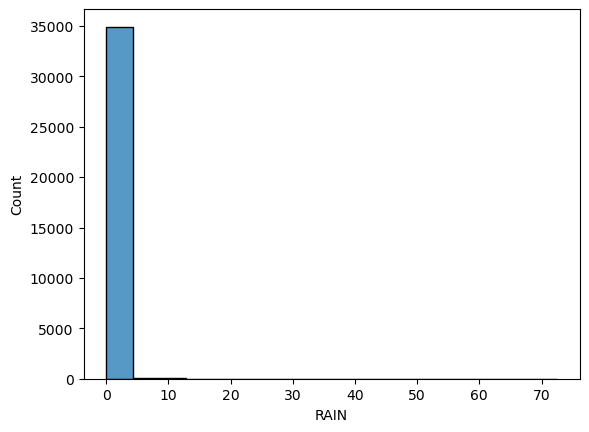

In [30]:
sns.histplot(prsa_data.RAIN)

<Axes: xlabel='WSPM', ylabel='Count'>

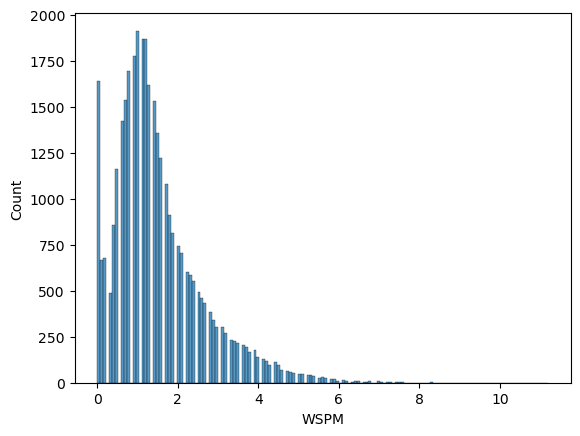

In [32]:
sns.histplot(prsa_data.WSPM)

#### Бинаризация атрибутов

In [36]:
prsa_data.RAIN[prsa_data.RAIN > 0]

267      0.1
268      0.4
269      0.1
270      0.9
271      0.9
        ... 
34891    0.2
34892    0.7
34893    0.9
34894    0.4
34895    0.2
Name: RAIN, Length: 1436, dtype: float64

In [38]:
is_rain = np.array(prsa_data.RAIN)
is_rain[is_rain > 0] = 1
prsa_data['IS_RAIN'] = is_rain
prsa_data.drop(['RAIN'], axis=1, inplace=True)
prsa_data.describe()

,No,SO2,NO2,CO,O3,PRES,WSPM,IS_RAIN
count,35064.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35050.000000,35044.000000
mean,17532.500000,18.376481,65.258789,1319.353513,48.873754,1011.097536,1.501215,0.040977
std,10122.249256,22.609648,37.996088,1268.114331,55.113576,10.355247,1.104472,0.198240
min,1.000000,0.285600,1.642400,100.000000,-0.275160,985.900000,0.000000,0.000000
25%,8766.750000,4.000000,36.000000,500.000000,3.579219,1002.500000,0.800000,0.000000
50%,17532.500000,10.000000,60.000000,900.000000,31.945652,1010.800000,1.200000,0.000000
75%,26298.250000,23.000000,88.000000,1600.000000,72.876079,1019.400000,2.000000,0.000000
max,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,11.200000,1.000000


#### Визуализация связи атрибутов с целевой переменной

<Axes: xlabel='SO2', ylabel='Density'>

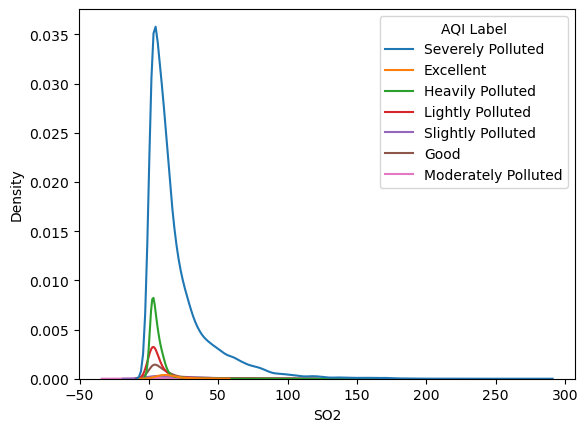

In [44]:
sns.kdeplot(data=prsa_data, x="SO2", hue="AQI Label")

<Axes: xlabel='NO2', ylabel='Density'>

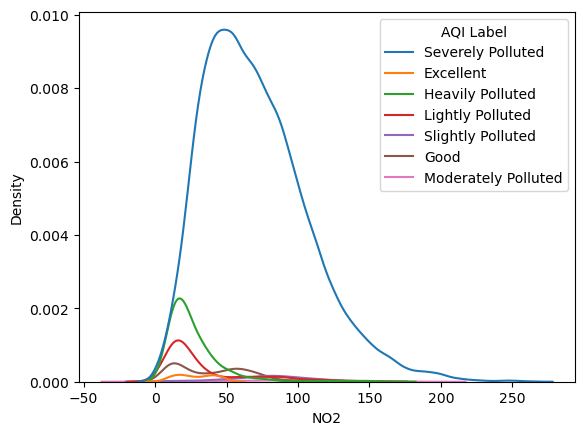

In [45]:
sns.kdeplot(data=prsa_data, x="NO2", hue="AQI Label")

C:\Users\Home\AppData\Local\Temp\ipykernel_4140\491964310.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")


<Axes: xlabel='CO', ylabel='Density'>

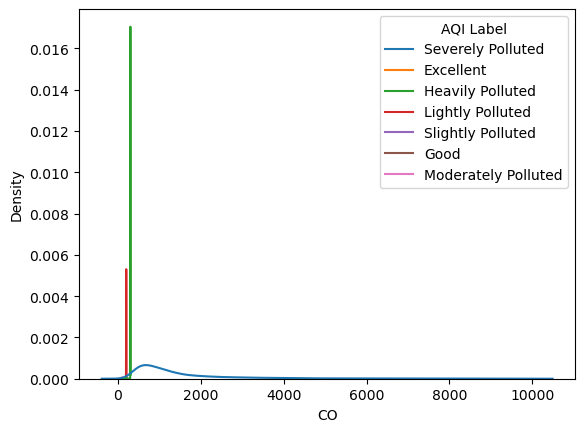

In [47]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")

C:\Users\Home\AppData\Local\Temp\ipykernel_4140\2756761127.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)


<Axes: xlabel='CO', ylabel='Density'>

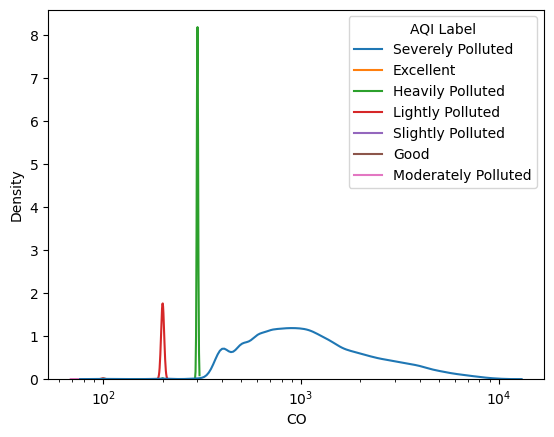

In [49]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)

<Axes: xlabel='O3', ylabel='Density'>

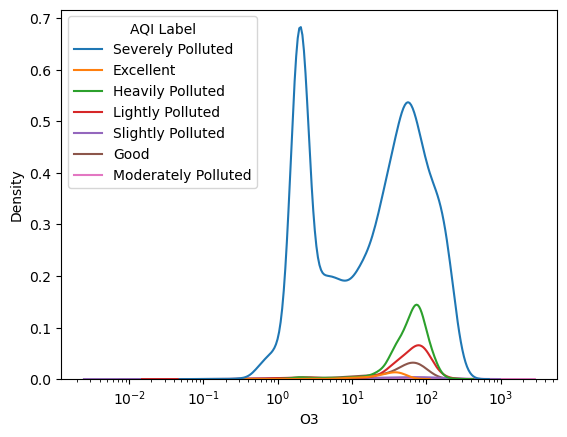

In [52]:
sns.kdeplot(data=prsa_data, x="O3", hue="AQI Label", log_scale=True)

#### Группировка численных значений

/tmp/ipykernel_3275/2756761127.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)


<Axes: xlabel='CO', ylabel='Density'>

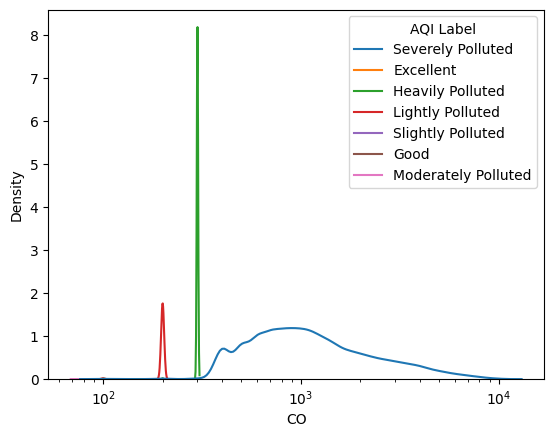

In [ ]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)

In [56]:
bin_ranges = [0, 250, 320, 10000]
bin_names = [1, 2, 3]
prsa_data['CO_bin_custom_label'] = pd.cut(np.array(prsa_data['CO']),
                                               bins=bin_ranges, labels=bin_names)
prsa_data.head()

,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,NaN
4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


In [58]:
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].values.add_categories(0)
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].fillna(0).astype(int)
prsa_data.head()

,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,0
4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


#### Удаление экстремальных значений

In [64]:
prsa_data.PRES[prsa_data.PRES <= 992] = 992
prsa_data.PRES[prsa_data.PRES >= 1034] = 1034

C:\Users\Home\AppData\Local\Temp\ipykernel_4140\3964902396.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  prsa_data.PRES[prsa_data.PRES <= 992] = 992
C:\Users\Home\AppData\Local\Temp\ipykernel_4140\3964902396.py:1: SettingWithCopyWarnin

<Axes: xlabel='PRES', ylabel='Count'>

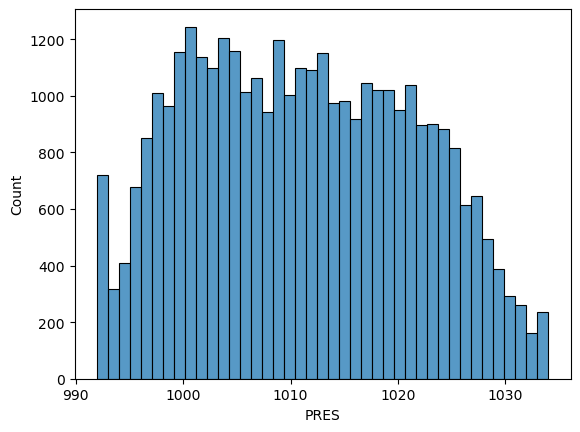

In [66]:
sns.histplot(prsa_data.PRES)

#### Заполнение пропусков

<Axes: >

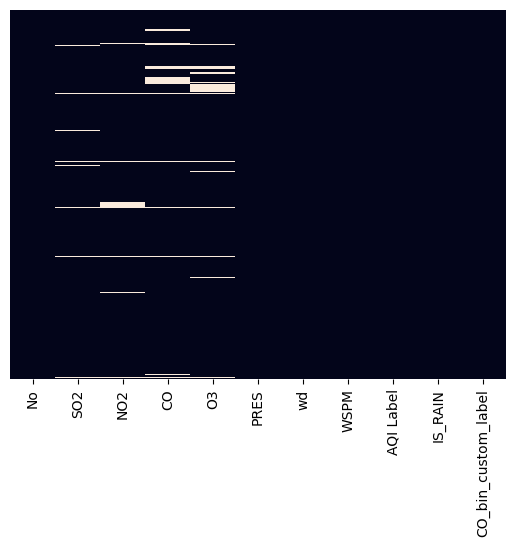

In [70]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)

In [72]:
undef = prsa_data.isnull().sum(axis=1)
undef[undef >= 2]

3        2
276      3
435      2
459      2
555      2
        ..
34880    4
34883    4
34885    4
35029    2
35030    2
Length: 884, dtype: int64

In [74]:
prsa_data = prsa_data.drop(undef[undef >= 2].index, axis=0)

<Axes: >

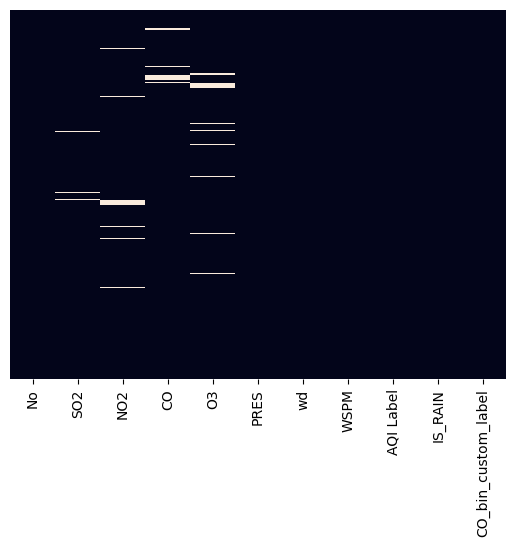

In [76]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)

In [78]:
prsa_data.isnull().sum()

No                        0
SO2                     281
NO2                     702
CO                     1028
O3                     1300
PRES                      0
wd                        0
WSPM                      0
AQI Label                 0
IS_RAIN                   0
CO_bin_custom_label       0
dtype: int64

In [80]:
prsa_data.SO2 = prsa_data.SO2.fillna(prsa_data.PRES.mean())

In [82]:
filler = prsa_data.O3[prsa_data.O3.isna()]

In [84]:
filler = prsa_data.O3[~prsa_data.O3.isna()].sample(n=len(filler)).set_axis(filler.index)

In [86]:
prsa_data.O3 = prsa_data.O3.fillna(filler)

<Axes: xlabel='O3', ylabel='Count'>

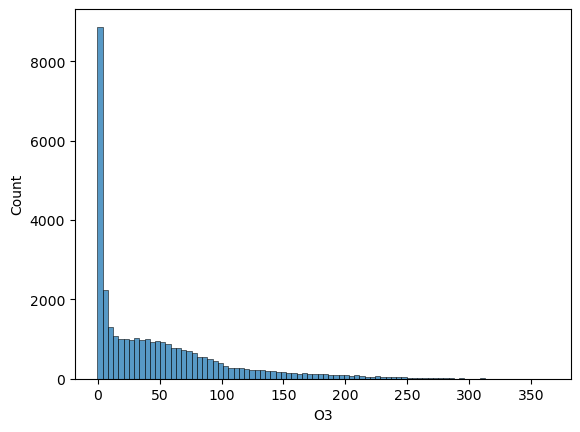

In [88]:
sns.histplot(prsa_data.O3)

#### Округление атрибутов

In [103]:
prsa_data['O3'] = np.array(np.round((prsa_data['O3'])), dtype='int')
prsa_data.head()

,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,1,0.583198,28.0,400.0,52,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,2,0.583198,28.0,400.0,50,1023.2,N,4.7,Severely Polluted,0.0,3
2,3,1.934235,19.0,400.0,55,1023.5,NNW,5.6,Severely Polluted,0.0,3
4,5,0.787195,NaN,300.0,54,1025.2,N,2.0,Heavily Polluted,0.0,2
5,6,0.732099,17.0,300.0,54,1025.6,N,3.7,Heavily Polluted,0.0,2


#### Логарифмирование атрибутов

### Задания для самостоятельного выполнения

#### 1. При выполнении 3 и 5 заданий используйте другие методы визуализации. Найдите самый подходящий тип графика для каждого распределения.

3 - Постройте визуализацию распределения каждого численного атрибута.

5 - Постройте совместное распределение каждого признака вместе с целевой переменной. Сделайте вывод о необходимости проведения группировки данных.

In [115]:
print(prsa_data.columns.tolist())

['No', 'SO2', 'NO2', 'CO', 'O3', 'PRES', 'wd', 'WSPM', 'AQI Label', 'IS_RAIN', 'CO_bin_custom_label']


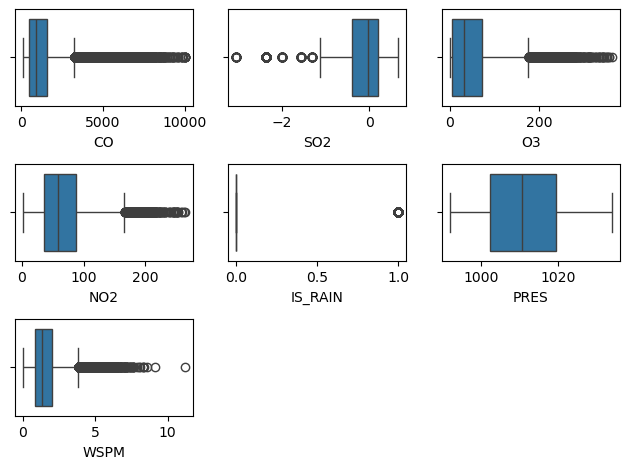

In [119]:
num_cols = ['CO', 'SO2', 'O3', 'NO2', 'IS_RAIN', 'PRES', 'WSPM']
plt.figure()
for i, col in enumerate(num_cols):
  plt.subplot(3,3,i+1)
  sns.boxplot(x=prsa_data[col])

plt.tight_layout()
plt.show()

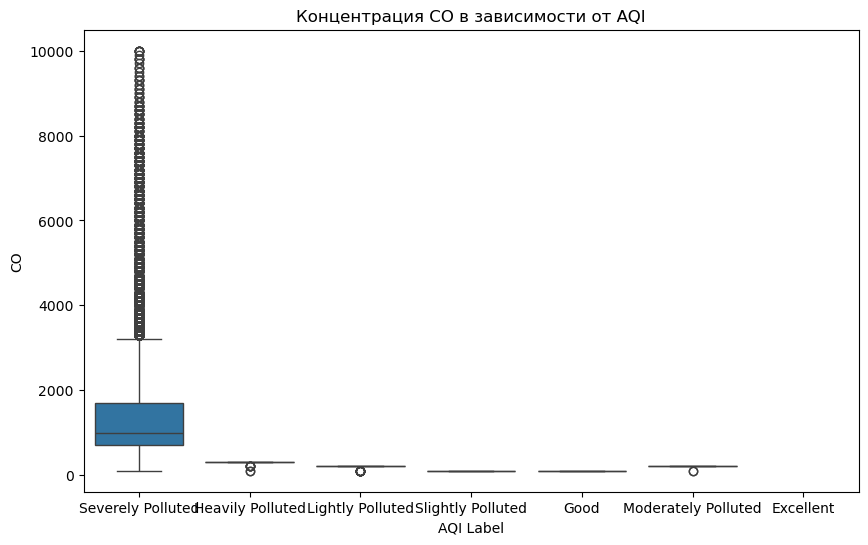

In [121]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=prsa_data, x='AQI Label', y='CO')
plt.title('Концентрация CO в зависимости от AQI')
plt.show()

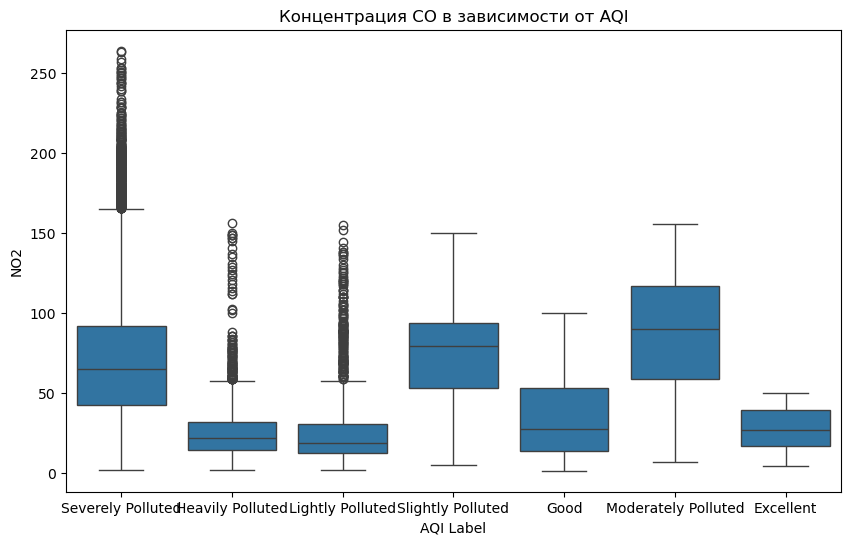

In [123]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=prsa_data, x='AQI Label', y='NO2')
plt.title('Концентрация CO в зависимости от AQI')
plt.show()

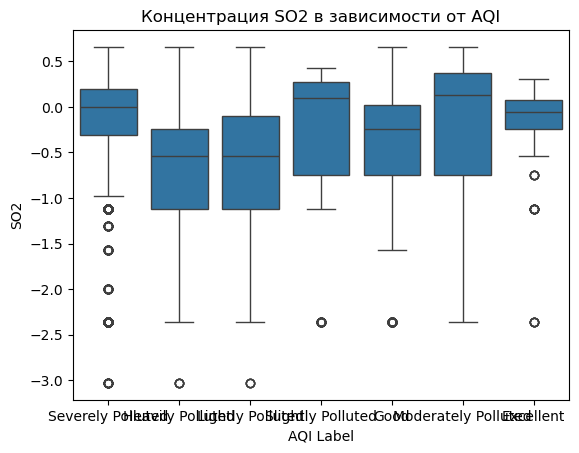

Text(0.5, 1.0, 'Концентрация O3 в зависимости от AQI')

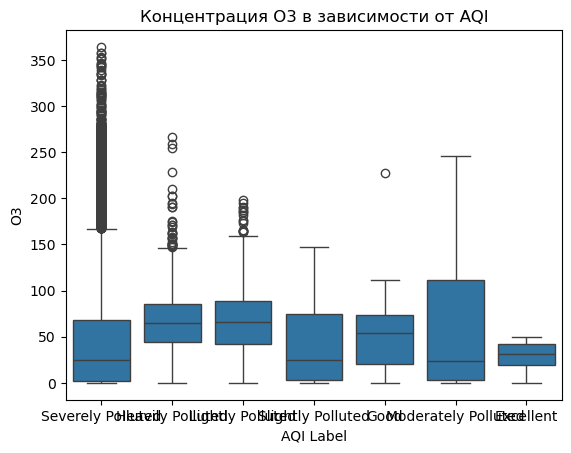

In [125]:
sns.boxplot(data=prsa_data, x='AQI Label', y='SO2')
plt.title('Концентрация SO2 в зависимости от AQI')
plt.show()
plt.figure()
sns.boxplot(data=prsa_data, x='AQI Label', y='O3')
plt.title('Концентрация O3 в зависимости от AQI')

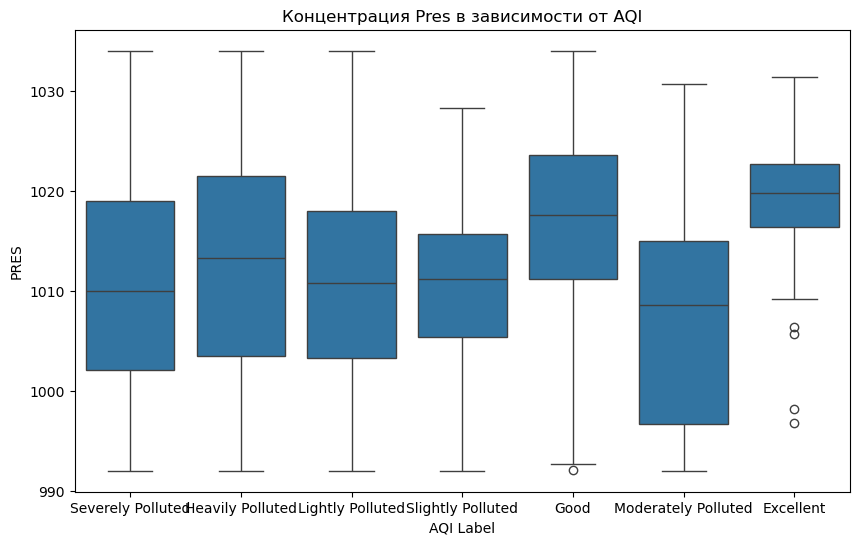

In [127]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=prsa_data, x='AQI Label', y='PRES')
plt.title('Концентрация Pres в зависимости от AQI')
plt.show()

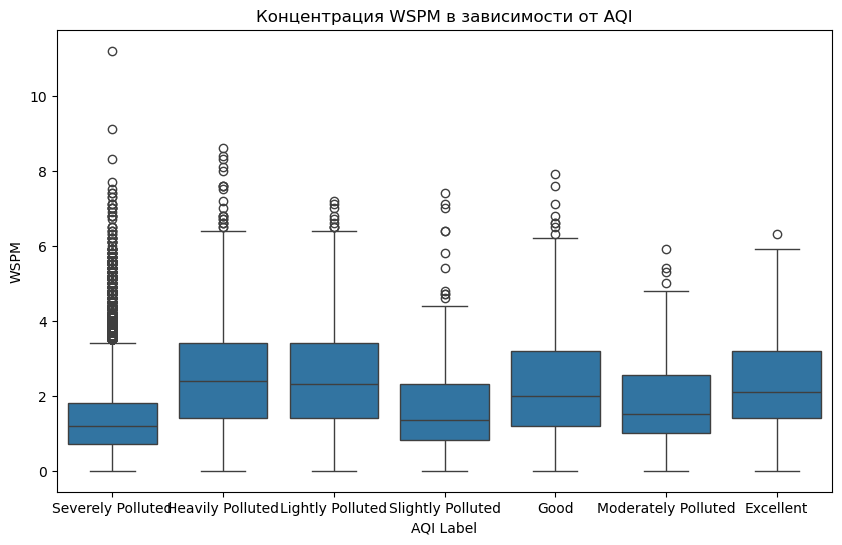

In [133]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=prsa_data, x='AQI Label', y='WSPM')
plt.title('Концентрация WSPM в зависимости от AQI')
plt.show()

#### 2. При выполнении 6 задания мы явно подбирали руками границы диапазона для клиппинга. Реализуйте адаптивный клиппинг через процентили.

<Axes: xlabel='PRES', ylabel='Count'>

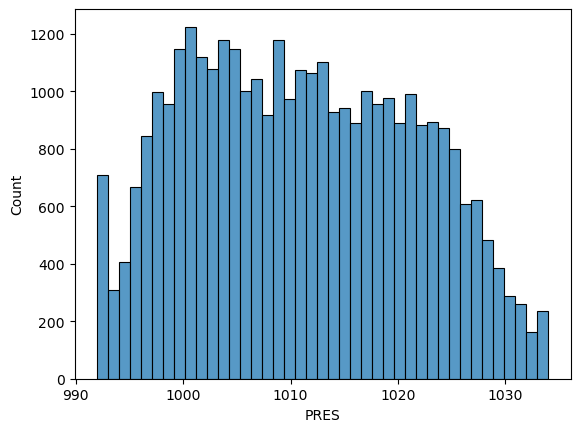

In [136]:
sns.histplot(prsa_data.PRES)

In [138]:
prsa_data.PRES = prsa_data.PRES.clip(lower=prsa_data.PRES.quantile(0.1), upper= prsa_data.PRES.quantile(0.9))
prsa_data.PRES

0        1023.0
1        1023.2
2        1023.5
4        1025.2
5        1025.2
          ...  
35059    1011.9
35060    1012.3
35061    1012.8
35062    1012.9
35063    1012.6
Name: PRES, Length: 34180, dtype: float64

<Axes: xlabel='PRES', ylabel='Count'>

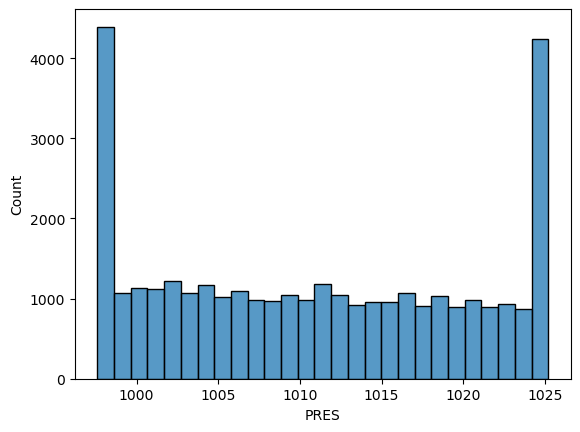

In [140]:
sns.histplot(prsa_data.PRES)

#### 3. Избавьтесь от оставшихся пропусков в данных. Самостоятельно выберите метод.

In [143]:
prsa_data.head(10)

,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,1,-0.539228,28.0,400.0,52,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,2,-0.539228,28.0,400.0,50,1023.2,N,4.7,Severely Polluted,0.0,3
2,3,0.659712,19.0,400.0,55,1023.5,NNW,5.6,Severely Polluted,0.0,3
4,5,-0.239279,NaN,300.0,54,1025.2,N,2.0,Heavily Polluted,0.0,2
5,6,-0.311839,17.0,300.0,54,1025.2,N,3.7,Heavily Polluted,0.0,2
6,7,-0.181483,21.0,300.0,52,1025.2,NNE,2.5,Heavily Polluted,0.0,2
7,8,-0.133998,26.0,300.0,47,1025.2,NNW,3.8,Heavily Polluted,0.0,2
8,9,-0.030024,39.0,400.0,36,1025.2,NNW,4.1,Severely Polluted,0.0,3
9,10,-0.094052,31.0,400.0,46,1025.2,N,2.6,Severely Polluted,0.0,3
10,11,-0.094052,30.0,400.0,49,1025.2,NNW,3.6,Severely Polluted,0.0,3


In [145]:
prsa_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34180 entries, 0 to 35063
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No                   34180 non-null  int64  
 1   SO2                  27890 non-null  float64
 2   NO2                  33478 non-null  float64
 3   CO                   33152 non-null  float64
 4   O3                   34180 non-null  int32  
 5   PRES                 34180 non-null  float64
 6   wd                   34180 non-null  object 
 7   WSPM                 34180 non-null  float64
 8   AQI Label            34180 non-null  object 
 9   IS_RAIN              34180 non-null  float64
 10  CO_bin_custom_label  34180 non-null  int32  
dtypes: float64(6), int32(2), int64(1), object(2)
memory usage: 2.9+ MB


In [149]:
cols_to_fix = ['SO2', 'NO2', 'CO', 'O3', 'PRES', 'IS_RAIN', 'WSPM']
prsa_data[cols_to_fix] = prsa_data[cols_to_fix].interpolate(method='linear')
prsa_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34180 entries, 0 to 35063
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No                   34180 non-null  int64  
 1   SO2                  34180 non-null  float64
 2   NO2                  34180 non-null  float64
 3   CO                   34180 non-null  float64
 4   O3                   34180 non-null  int32  
 5   PRES                 34180 non-null  float64
 6   wd                   34180 non-null  object 
 7   WSPM                 34180 non-null  float64
 8   AQI Label            34180 non-null  object 
 9   IS_RAIN              34180 non-null  float64
 10  CO_bin_custom_label  34180 non-null  int32  
dtypes: float64(6), int32(2), int64(1), object(2)
memory usage: 2.9+ MB


#### 4. Проведите нормализацию численных признаков. Выберите наиболее подходящий вид нормализации для каждого признака.

In [156]:
ss=StandardScaler()
rs = RobustScaler()

In [160]:
prsa_data[['PRES']] = ss.fit_transform(prsa_data[['PRES']])

robust_cols = ['SO2', 'NO2', 'CO', 'O3', 'IS_RAIN', 'WSPM']
prsa_data[robust_cols] = rs.fit_transform(prsa_data[robust_cols])

In [162]:
prsa_data.describe()

,No,SO2,NO2,CO,O3,PRES,WSPM,IS_RAIN,CO_bin_custom_label
count,34180.000000,34180.000000,34180.000000,34180.000000,34180.000000,3.418000e+04,34180.000000,34180.000000,34180.000000
mean,17691.018929,-0.389798,0.100951,0.385932,0.244505,-1.995673e-17,0.174722,0.041545,2.739321
std,10089.433202,0.955260,0.726235,1.149134,0.798772,1.000015e+00,0.922936,0.199549,0.687850
min,1.000000,-3.124842,-1.118949,-0.727273,-0.463768,-1.426393e+00,-1.083333,0.000000,0.000000
25%,9121.750000,-0.698905,-0.460176,-0.363636,-0.405797,-9.146374e-01,-0.416667,0.000000,3.000000
50%,17742.500000,0.000000,0.000000,0.000000,0.000000,-4.038751e-02,0.000000,0.000000,3.000000
75%,26414.250000,0.301095,0.539824,0.636364,0.594203,8.978319e-01,0.583333,0.000000,3.000000
max,35064.000000,0.855963,3.911496,8.272727,4.811594,1.516204e+00,8.250000,1.000000,3.000000


#### 5. Постройте кореллограмму по всем численным столбцам датасета. Сделайте вывод о значимости признаков.

Text(0.5, 1.0, 'Коррелограмма признаков PRSA')

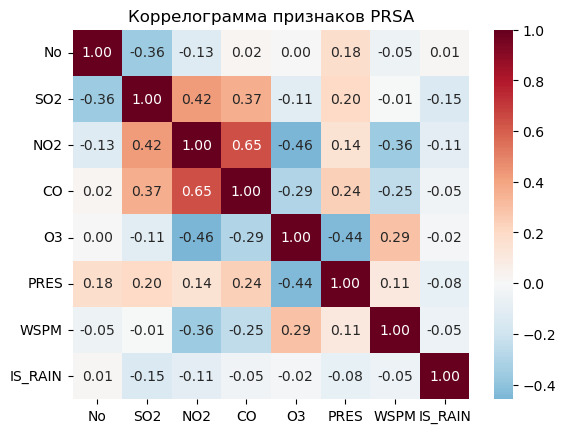

In [165]:
num_cols = prsa_data.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = prsa_data[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Коррелограмма признаков PRSA')

#### 6. Визуализируйте связи между признаками. Сделайте вывод об их взаимозависимости.

Text(0.5, 1.02, 'Связи между основными признаками и AQI Label')

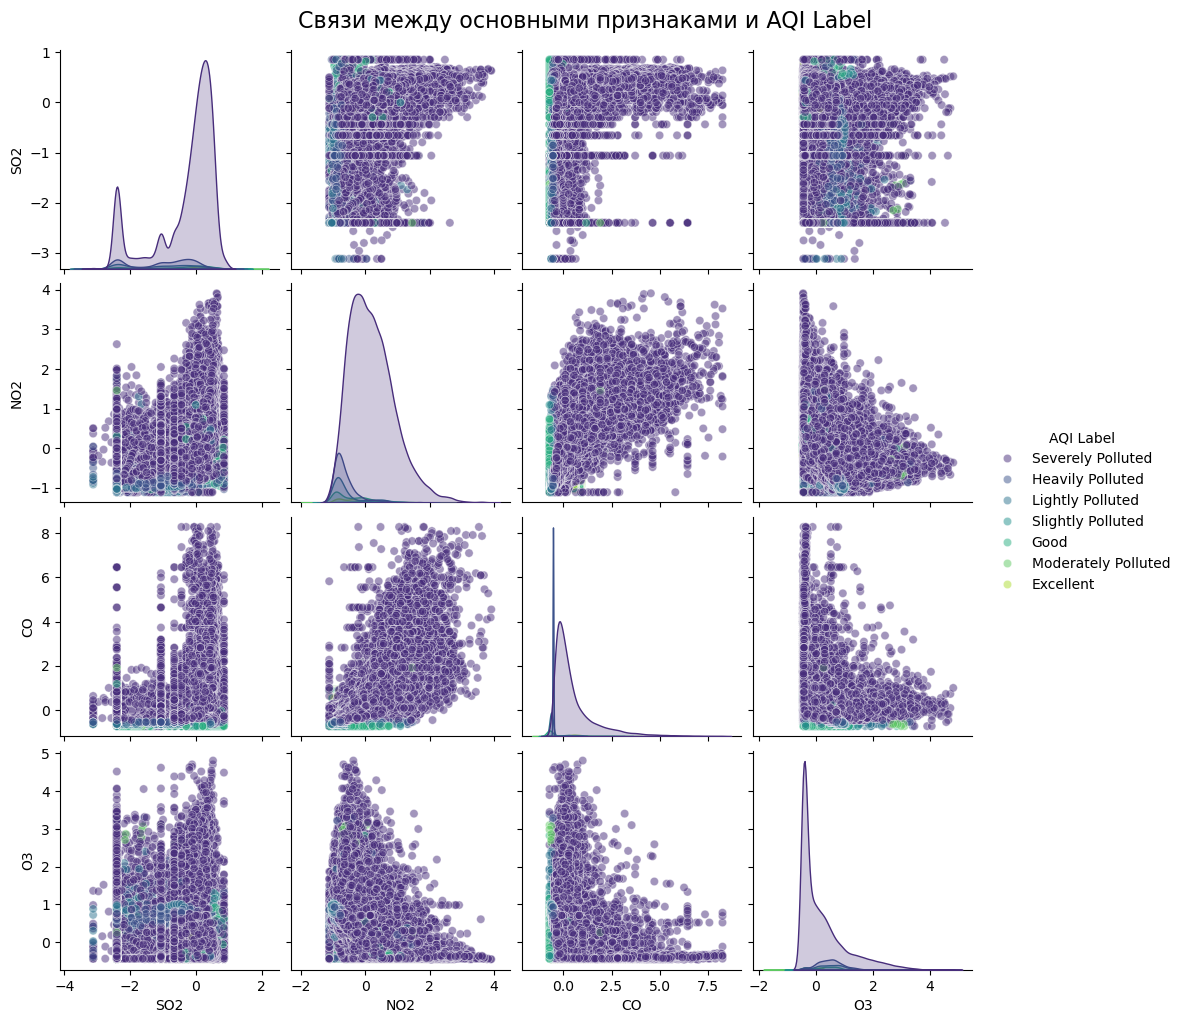

In [168]:
cols_to_plot = ['SO2', 'NO2', 'CO', 'O3', 'AQI Label']
plot_data = prsa_data[cols_to_plot]

g = sns.pairplot(plot_data, hue='AQI Label', diag_kind='kde', palette='viridis', plot_kws={'alpha': 0.5})
g.fig.suptitle('Связи между основными признаками и AQI Label', y=1.02, fontsize=16)